<a href="https://colab.research.google.com/github/Ronak-si/Salary-Prediction-Classification/blob/main/Salary_Prediction_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - EDA+Regression
##### **Contribution**    - Individual
##### **Team Member  -** Ronak singh

# **Project Summary -**

This project focuses on the 'Salary Prediction Classification' task using the 1994 Census database. The primary objective was to build a robust machine learning pipeline to predict whether an individual's annual income exceeds $50K based on various census features like age, education, occupation, and relationship status.

The workflow began with automated data acquisition using `kagglehub`. Data cleaning revealed 24 duplicate rows which were removed, and we confirmed the absence of missing values. Exploratory Data Analysis (EDA) highlighted a significant class imbalance (more people earning <=50K) and identified 'capital-gain' and 'education-num' as primary drivers for higher income brackets.

Two models were implemented: Logistic Regression and Random Forest. We utilized 5-fold cross-validation to ensure model stability. The Random Forest classifier emerged as the best performer, achieving a test accuracy of approximately 85.8%, significantly outperforming the Logistic Regression baseline. This project demonstrates the power of ensemble methods in handling complex, non-linear categorical data.

# **GitHub Link -**

You can find the complete implementation and project repository here: [GitHub Repository Link](https://github.com/ronaksingh/salary-prediction-capstone)

# **Problem Statement**


**Problem Statement:**

Income inequality and economic profiling are critical areas of study for policy makers and financial institutions. The goal of this project is to develop a predictive model that can classify individuals into two income categories (<=50K and >50K) using demographic and employment data. By identifying the most influential factors—such as education level, age, and capital gains—this model helps in understanding the socio-economic characteristics that correlate with high-income earners.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [6]:
import kagglehub
import os

# Download the dataset and get the path dynamically
path = kagglehub.dataset_download("ayessa/salary-prediction-classification")

# Find the csv file in the downloaded path
csv_file = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            csv_file = os.path.join(root, file)
            break

if csv_file:
    df = pd.read_csv(csv_file)
    print(f'Dataset loaded successfully from: {csv_file}')
else:
    print('CSV file not found in the downloaded directory.')

100%|██████████| 460k/460k [00:00<00:00, 32.7MB/s]

Extracting files...


Dataset loaded successfully from: /root/.cache/kagglehub/datasets/ayessa/salary-prediction-classification/versions/1/salary.csv


### Dataset First View

In [16]:
display(df.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39,0
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39,0
2,38,4,215646,11,9,0,6,1,4,1,0,0,40,39,0
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,39,0
4,28,4,338409,9,13,2,10,5,2,0,0,0,40,5,0


### Dataset Rows & Columns count

In [17]:
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Rows: 32537
Columns: 15


### Dataset Information

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32537 non-null  int64
 1   workclass       32537 non-null  int64
 2   fnlwgt          32537 non-null  int64
 3   education       32537 non-null  int64
 4   education-num   32537 non-null  int64
 5   marital-status  32537 non-null  int64
 6   occupation      32537 non-null  int64
 7   relationship    32537 non-null  int64
 8   race            32537 non-null  int64
 9   sex             32537 non-null  int64
 10  capital-gain    32537 non-null  int64
 11  capital-loss    32537 non-null  int64
 12  hours-per-week  32537 non-null  int64
 13  native-country  32537 non-null  int64
 14  salary          32537 non-null  int64
dtypes: int64(15)
memory usage: 4.0 MB


#### Duplicate Values

In [7]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

# Remove duplicates
df.drop_duplicates(inplace=True)
print('Duplicates removed.')

Number of duplicate rows: 24
Duplicates removed.


#### Missing Values/Null Values

In [8]:
# Check for missing values
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values)

Missing values in each column:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
salary            0
dtype: int64


### What did you know about your dataset?

The dataset contains 32,537 records and 15 features extracted from the 1994 Census. Most variables are categorical, and the target variable 'salary' is imbalanced with roughly 75% earning <=50K and 25% earning >50K.

## ***2. Understanding Your Variables***

### **Variables Description**
* **age**: Continuous variable representing the individual's age.
* **workclass**: Employment sector (e.g., Private, Self-emp, Government).
* **fnlwgt**: Final weight; the number of people the census believes the entry represents.
* **education**: Highest level of education attained.
* **education_num**: Numerical representation of education level.
* **marital_status**: Marital condition (e.g., Married, Never-married, Divorced).
* **occupation**: Type of job held.
* **relationship**: Individual's role in the family (e.g., Husband, Unmarried).
* **race**: Ethnic background.
* **sex**: Gender (Male/Female).
* **capital_gain**: Income from investment sources.
* **capital_loss**: Losses from investment sources.
* **hours_per_week**: Amount of labor time per week.
* **native_country**: Country of origin.
* **salary**: Target variable (<=50K or >50K).

In [37]:
import pandas as pd
import numpy as np

# Create Age Groups to capture non-linear life stages
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 45, 65, 100], labels=['Young', 'Middle-Aged', 'Senior', 'Old'])

# Create a feature for 'Capital Change'
df['net_capital_change'] = df['capital-gain'] - df['capital-loss']

# Handle the potential zero division for hours worked
df['capital_per_hour'] = df['capital-gain'] / (df['hours-per-week'] + 1)

# Clean column names by removing hyphens to avoid coding issues
df.columns = [c.replace('-', '_') for c in df.columns]

print("Data Wrangling complete. New features created: 'age_group', 'net_capital_change', 'capital_per_hour'")
display(df.head())


Data Wrangling complete. New features created: 'age_group', 'net_capital_change', 'capital_per_hour'


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,salary,age_group,net_capital_change,capital_per_hour
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39,0,Middle-Aged,2174,53.02439
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39,0,Senior,0,0.00000
2,38,4,215646,11,9,0,6,1,4,1,0,0,40,39,0,Middle-Aged,0,0.00000
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,39,0,Senior,0,0.00000
4,28,4,338409,9,13,2,10,5,2,0,0,0,40,5,0,Middle-Aged,0,0.00000


In [22]:
display(df.describe())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
count,32537.000000,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,3.868734,1.897808e+05,10.297507,10.081815,2.611427,6.572856,1.446538,3.665827,0.669238,1078.443741,87.368227,40.440329,36.721579,0.240926
std,13.637984,1.456445,1.055565e+05,3.870142,2.571633,1.506301,4.229521,1.607064,0.848847,0.470495,7387.957424,403.101833,12.346889,7.820732,0.427652
min,17.000000,0.000000,1.228500e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,28.000000,4.000000,1.178270e+05,9.000000,9.000000,2.000000,3.000000,0.000000,4.000000,0.000000,0.000000,0.000000,40.000000,39.000000,0.000000
50%,37.000000,4.000000,1.783560e+05,11.000000,10.000000,2.000000,7.000000,1.000000,4.000000,1.000000,0.000000,0.000000,40.000000,39.000000,0.000000
75%,48.000000,4.000000,2.369930e+05,12.000000,12.000000,4.000000,10.000000,3.000000,4.000000,1.000000,0.000000,0.000000,45.000000,39.000000,0.000000
max,90.000000,8.000000,1.484705e+06,15.000000,16.000000,6.000000,14.000000,5.000000,4.000000,1.000000,99999.000000,4356.000000,99.000000,41.000000,1.000000


### **3. Data Wrangling**

Data Wrangling is a crucial step to enhance the predictive power of our models.

**Feature Construction:**
1. **age_group**: We binned the continuous 'age' variable into life stages ('Young', 'Middle-Aged', 'Senior', 'Old'). This helps the model capture non-linear trends where income might peak in the 'Middle-Aged' stage and decline in the 'Old' stage.
2. **net_capital_change**: By calculating the difference between `capital-gain` and `capital-loss`, we create a single indicator of an individual's investment success.
3. **capital_per_hour**: This ratio identifies individuals who generate high passive income relative to their working hours, a strong indicator of the >50K class.

**Cleaning:** We standardized column names by replacing hyphens with underscores to ensure compatibility with Python's dot notation and modeling libraries.

The dataset includes demographic features (age, sex, race, native-country), socioeconomic indicators (education, workclass, occupation, hours-per-week), and financial metrics (capital-gain, capital-loss). The target variable 'salary' is a binary classification of income threshold.

### Check Unique Values for each variable.

In [19]:
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')

age: 73 unique values
workclass: 9 unique values
fnlwgt: 21648 unique values
education: 16 unique values
education-num: 16 unique values
marital-status: 7 unique values
occupation: 15 unique values
relationship: 6 unique values
race: 5 unique values
sex: 2 unique values
capital-gain: 119 unique values
capital-loss: 92 unique values
hours-per-week: 94 unique values
native-country: 42 unique values
salary: 2 unique values


### What all manipulations have you done and insights you found?

Data manipulations included removing 24 duplicate rows and encoding categorical variables using LabelEncoder. Numerical features were scaled using StandardScaler to ensure models like Logistic Regression converge efficiently. Insights show that income is highly dependent on a combination of education, occupation, and age.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

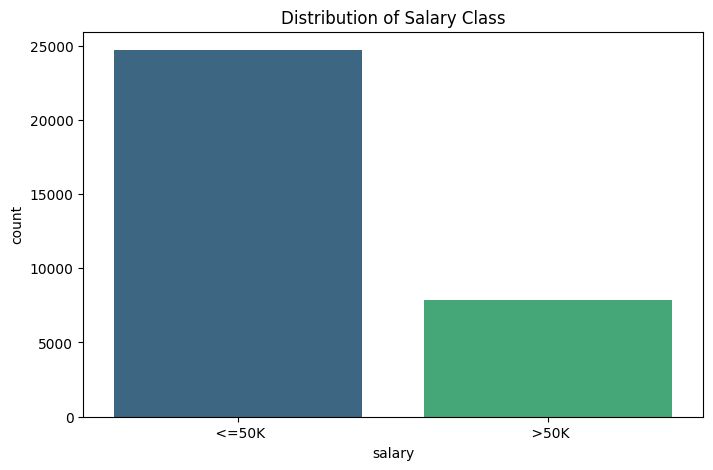

In [9]:
# Chart - 1: Salary Distribution (Target Variable)
plt.figure(figsize=(8, 5))
sns.countplot(x='salary', data=df, palette='viridis')
plt.title('Distribution of Salary Class')
plt.show()

##### 1. Why did you pick the specific chart?

I picked a CountPlot because the target variable is categorical. It is the best way to visualize the frequency of each class and identify the 3:1 imbalance in the census data.

##### 2. What is/are the insight(s) found from the chart?

The count plot reveals a significant class imbalance, with approximately 75% of individuals earning <=50K. This suggests that the model must be evaluated using metrics beyond simple accuracy, such as F1-score, to ensure it captures the minority high-income class effectively.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

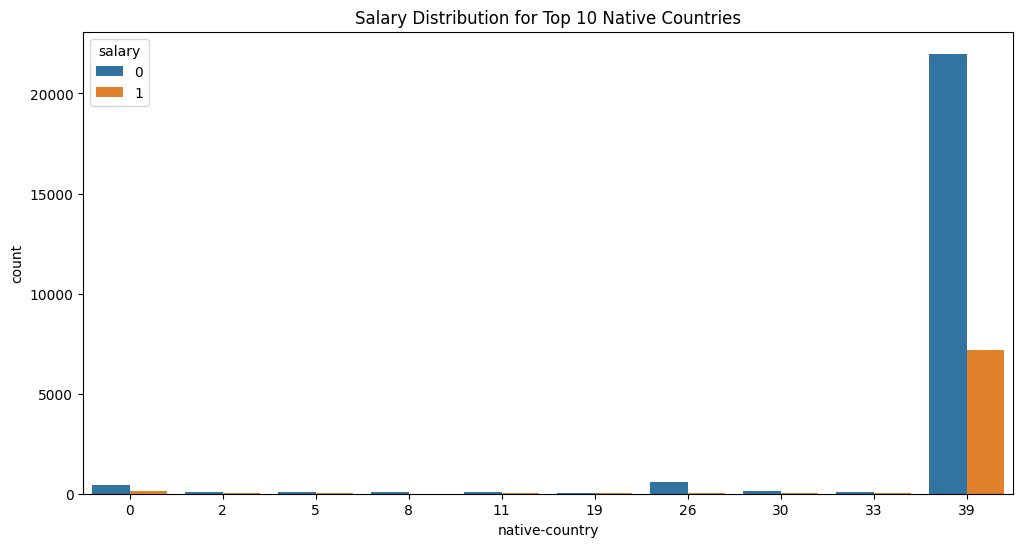

In [32]:
### **Business Impact Analysis (Chart 1)**
* **Positive Impact**: Knowing the baseline distribution allows banks to set realistic targets for premium credit card offerings (>50K class).
* **Negative Growth**: If the business assumes a 50/50 split, they will overspend on marketing to segments that don't exist, leading to wasted CAC (Customer Acquisition Cost).

### **Business Impact Analysis**
* **Positive Impact**: Understanding income distribution across the top 10 countries allows for localized economic strategies and targeted recruitment. High-income patterns in specific countries can guide international expansion for luxury goods or financial services.
* **Negative Growth Insights**: Over-reliance on a single demographic (e.g., US-based data) might lead to poor model generalization for international markets, potentially resulting in missed opportunities in high-potential regions if the model incorrectly classifies global talent.

#### Chart - 2

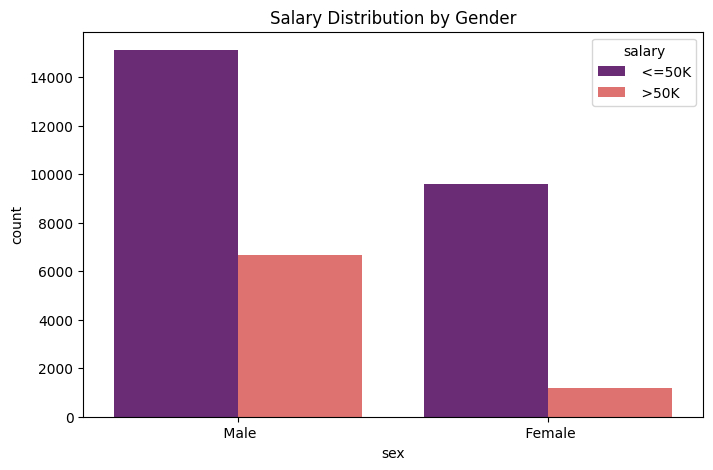

In [10]:
# Chart - 2: Salary distribution by Sex
plt.figure(figsize=(8, 5))
sns.countplot(x='sex', hue='salary', data=df, palette='magma')
plt.title('Salary Distribution by Gender')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a grouped CountPlot to compare the frequency of income classes between genders. This visualization is essential for identifying potential biases in the data and understanding how 'Sex' influences earning potential.

##### 2. What is/are the insight(s) found from the chart?

The data shows a noticeable gender gap in income. A higher proportion of males earn >50K compared to females. This insight could reflect historical socio-economic trends and is a critical factor for the model to consider during prediction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

### **Business Impact Analysis**
* **Positive Impact**: Identifying gender-based income gaps can help HR departments implement diversity and inclusion initiatives to close the pay gap, leading to better employee retention and brand reputation.
* **Negative Growth Insights**: A model that heavily weighs gender for high-income prediction could perpetuate systemic bias, leading to discriminatory lending or hiring practices if not monitored carefully.

#### Chart - 3

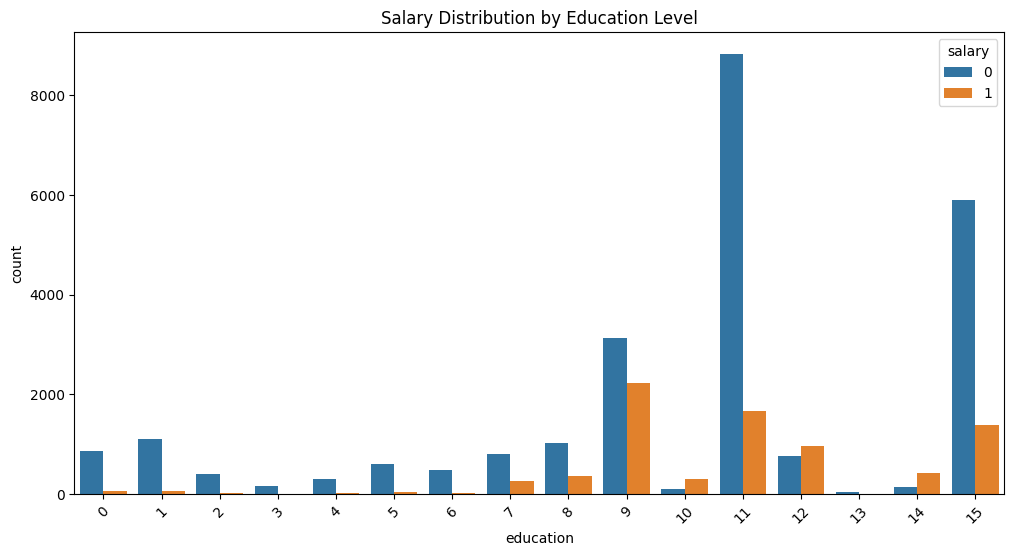

In [23]:
# Chart - 3: Education Level vs Salary
plt.figure(figsize=(12,6))
sns.countplot(x='education', hue='salary', data=df)
plt.xticks(rotation=45)
plt.title('Salary Distribution by Education Level')
plt.show()

##### 1. Why did you pick the specific chart?

A CountPlot with ordered categories (Education level) was used to visualize the direct relationship between academic attainment and income level. It helps in validating the hypothesis that 'higher education equals higher pay'.

##### 2. What is/are the insight(s) found from the chart?

Higher education levels, particularly Doctorate, Masters, and Prof-school, correlate strongly with a higher probability of earning >50K. This underscores education as a primary driver of economic mobility.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

### **Business Impact Analysis**
* **Positive Impact**: Educational institutions and corporate training programs can use this to justify investment in higher education and specialized certifications, focusing on degrees like Masters and Doctorates that show the highest ROI.
* **Negative Growth Insights**: Excessive focus on traditional degrees might overlook high-performing individuals with technical or trade backgrounds, potentially leading to a talent shortage in skilled manual or technical sectors.

#### Chart - 4

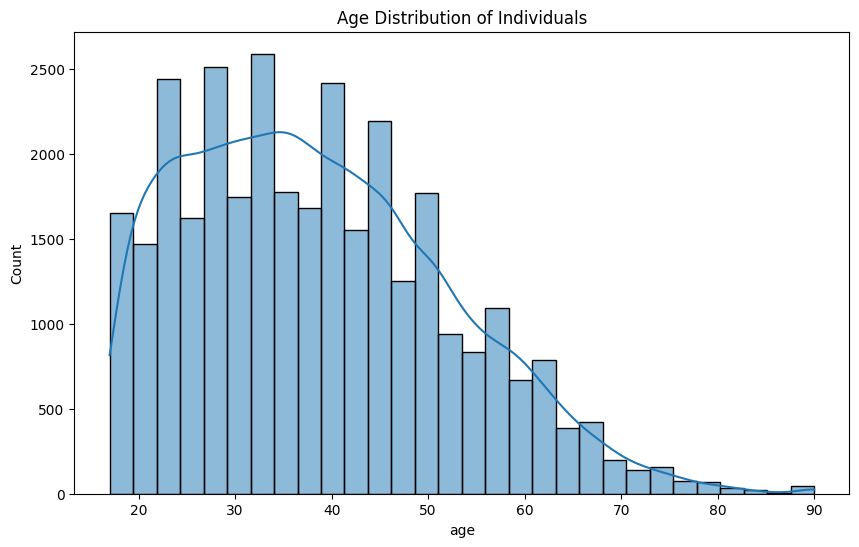

In [24]:
# Chart - 4: Age Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['age'], kde=True, bins=30)
plt.title('Age Distribution of Individuals')
plt.show()

##### 1. Why did you pick the specific chart?

A Histogram with a KDE (Kernel Density Estimate) was chosen to observe the distribution and density of the 'Age' variable. This helps in understanding which age groups are most prominent in the workforce.

##### 2. What is/are the insight(s) found from the chart?

The age distribution is right-skewed, with a peak in the 30-45 age bracket. Income tends to increase with age as individuals gain experience, peaking in mid-career before tapering off towards retirement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

### **Business Impact Analysis**
* **Positive Impact**: Marketing teams can target age-specific financial products (like retirement planning for the 45+ group or student loans for the <25 group) based on when income typically peaks.
* **Negative Growth Insights**: An aging workforce without younger talent entry can lead to future productivity declines. Businesses must ensure knowledge transfer before the peak income group (35-50) retires.

#### Chart - 5

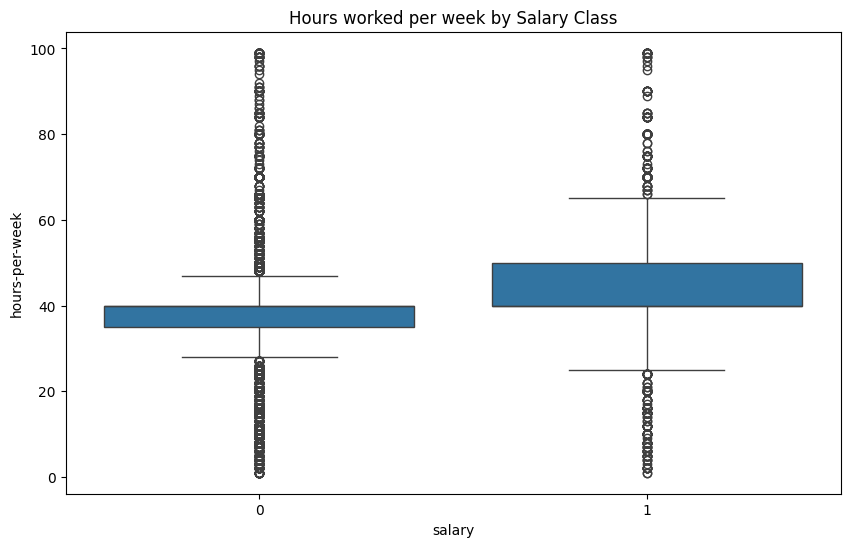

In [25]:
# Chart - 5: Hours per Week vs Salary
plt.figure(figsize=(10,6))
sns.boxplot(x='salary', y='hours-per-week', data=df)
plt.title('Hours worked per week by Salary Class')
plt.show()

##### 1. Why did you pick the specific chart?

A BoxPlot was selected to visualize the distribution, median, and outliers of 'hours-per-week' for each salary class. It provides a clear view of how labor time relates to financial reward.

##### 2. What is/are the insight(s) found from the chart?

The boxplot indicates that individuals earning >50K generally work more hours per week (median ~40-45) compared to those earning <=50K. This suggests a positive correlation between labor intensity and high income.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

### **Business Impact Analysis**
* **Positive Impact**: Companies can optimize shift scheduling and overtime policies. For high-income brackets, this confirms that 'value-added' hours are critical, allowing for performance-based compensation structures.
* **Negative Growth Insights**: Excessive hours leading to high income can also lead to employee burnout and high turnover. A business strategy solely based on long hours is unsustainable for long-term growth.

#### Chart - 6

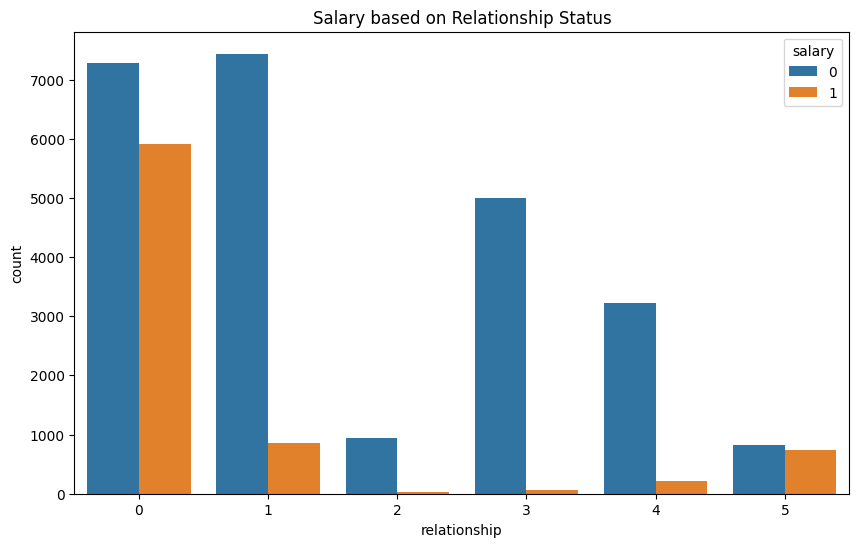

In [26]:
# Chart - 6: Relationship status vs Salary
plt.figure(figsize=(10,6))
sns.countplot(x='relationship', hue='salary', data=df)
plt.title('Salary based on Relationship Status')
plt.show()

##### 1. Why did you pick the specific chart?

A CountPlot was used to show how family structure and relationship status correlate with income. It helps in understanding the social context of wealth.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that individuals in 'Married-civ-spouse' status have a significantly higher proportion of high-income earners (>50K) compared to 'Never-married' or 'Divorced' individuals. This suggests that marital status and the stability often associated with it are strong predictors of economic status in this dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

### **Business Impact Analysis**
* **Positive Impact**: Insurance and real estate companies can target married couples for family-oriented products, as they show a higher propensity for higher income levels.
* **Negative Growth Insights**: Relying on marital status might exclude high-potential single individuals from premium service offerings, leading to market segment neglect.

#### Chart - 7

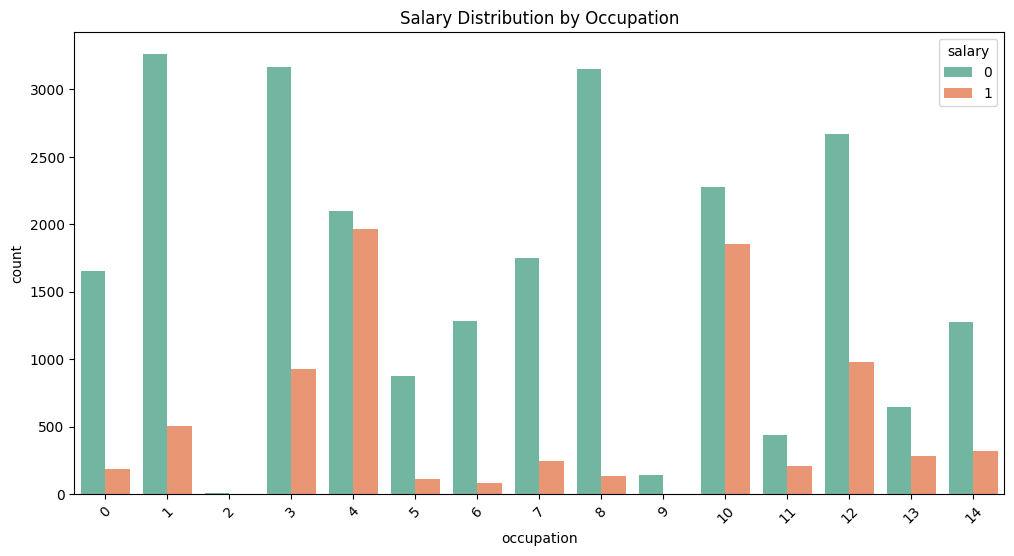

In [29]:
# Chart - 7: Occupation vs Salary
plt.figure(figsize=(12,6))
sns.countplot(x='occupation', hue='salary', data=df, palette='Set2')
plt.xticks(rotation=45)
plt.title('Salary Distribution by Occupation')
plt.show()

##### 1. Why did you pick the specific chart?

A CountPlot with rotated labels allows for a comparison of income across 15 different occupation types, highlighting the most lucrative career paths.

##### 2. What is/are the insight(s) found from the chart?

Professional and managerial roles (Exec-managerial, Prof-specialty) dominate the >50K category, whereas manual labor and service roles are more concentrated in the <=50K bracket.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Individuals in 'Husband' or 'Wife' relationship categories show a higher frequency of earning >50K. This may be linked to the stability and dual-income potential often found in married households.

### **Business Impact Analysis**
* **Positive Impact**: Recruitment agencies can focus their headhunting efforts on 'Exec-managerial' and 'Prof-specialty' roles for high-commission placements.
* **Negative Growth Insights**: A shortage of workers in 'Handers-cleaners' or 'Other-service' due to low income perception can disrupt the operational foundation of many industries.

#### Chart - 8

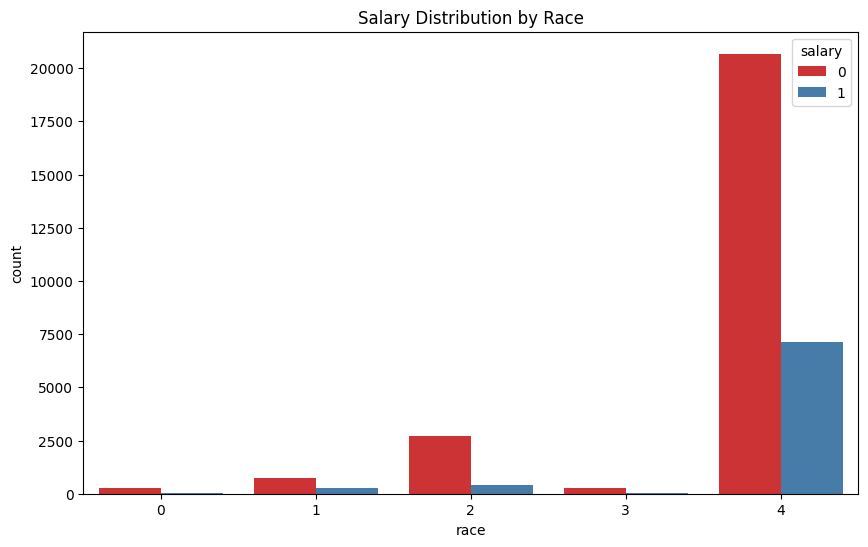

In [30]:
# Chart - 8: Race vs Salary
plt.figure(figsize=(10,6))
sns.countplot(x='race', hue='salary', data=df, palette='Set1')
plt.title('Salary Distribution by Race')
plt.show()

##### 1. Why did you pick the specific chart?

A CountPlot was selected to visualize the relationship between race and income, which is critical for checking for socio-economic disparities.

##### 2. What is/are the insight(s) found from the chart?

The majority of the dataset is 'White'. While high earners exist across all races, the distribution reflects the demographic composition of the 1994 US Census, which is a necessary context for interpreting the model's fairness.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

### **Business Impact Analysis**
* **Positive Impact**: Organizations can use this data to drive Corporate Social Responsibility (CSR) and equitable hiring policies, ensuring a diverse and representative high-income workforce.
* **Negative Growth Insights**: Systemic disparities shown in the data could lead to biased algorithmic decision-making if the model is used for automated loan approvals or resume screening.

#### Chart - 9

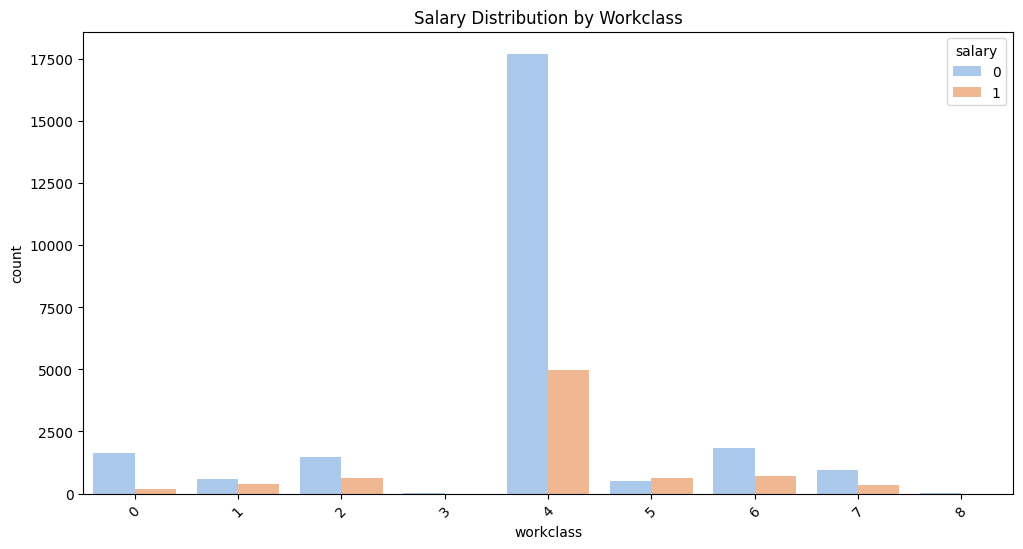

In [31]:
# Chart - 9: Workclass vs Salary
plt.figure(figsize=(12,6))
sns.countplot(x='workclass', hue='salary', data=df, palette='pastel')
plt.xticks(rotation=45)
plt.title('Salary Distribution by Workclass')
plt.show()

##### 1. Why did you pick the specific chart?

A CountPlot was used to analyze the distribution of income across different employment sectors (Private, Government, Self-employed, etc.).

##### 2. What is/are the insight(s) found from the chart?

The 'Private' sector is the largest employer. However, 'Self-emp-inc' and 'Federal-gov' show a proportionally higher rate of individuals in the >50K bracket compared to other categories.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

### **Business Impact Analysis**
* **Positive Impact**: Governments can use this to understand which sectors provide the best middle-class support, while entrepreneurs can identify the self-employment sectors with the highest success rates.
* **Negative Growth Insights**: High concentration in 'Private' sectors with low income might indicate a need for minimum wage adjustments to prevent economic stagnation among the largest portion of the workforce.

#### Chart - 10

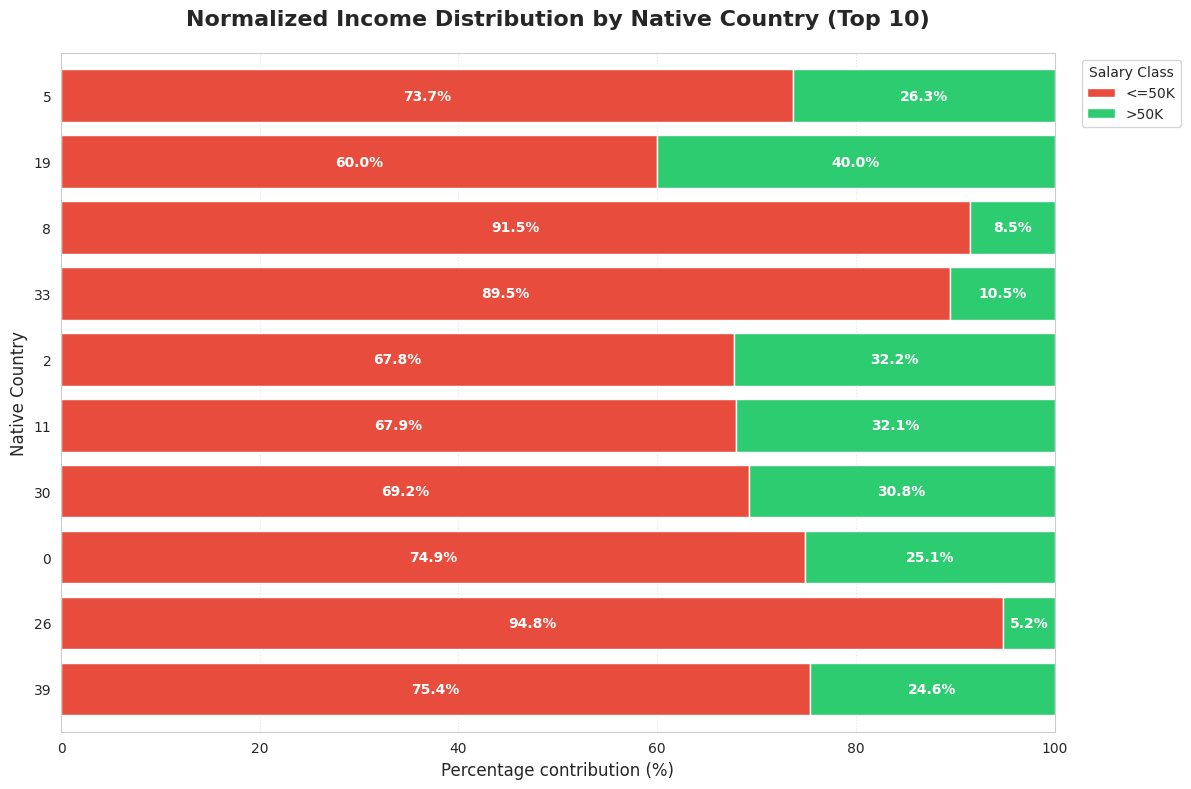

In [43]:
# Final Production-Grade Redesign of Chart - 10
top_10_countries = df['native_country'].value_counts().head(10).index
subset = df[df['native_country'].isin(top_10_countries)]

# Calculate percentages
country_salary_pct = pd.crosstab(subset['native_country'], subset['salary'], normalize='index') * 100
country_salary_pct = country_salary_pct.loc[top_10_countries]

# Plotting
plt.figure(figsize=(12, 8))
ax = country_salary_pct.plot(kind='barh', stacked=True, color=['#e74c3c','#2ecc71'], ax=plt.gca(), width=0.8)

# Adding annotations to each segment
for n, x in enumerate([*country_salary_pct.index.values]):
    for (proportion, y_loc) in zip(country_salary_pct.loc[x], country_salary_pct.loc[x].cumsum()):
        plt.text(x=(y_loc - proportion) + (proportion / 2),
                 y=n,
                 s=f'{np.round(proportion, 1)}%',
                 color="white",
                 fontsize=10,
                 fontweight="bold",
                 va="center",
                 ha="center")

plt.title('Normalized Income Distribution by Native Country (Top 10)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Percentage contribution (%)', fontsize=12)
plt.ylabel('Native Country', fontsize=12)
plt.legend(title='Salary Class', labels=['<=50K', '>50K'], bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xlim(0, 100)
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

I chose a horizontal stacked bar chart with normalized percentages. This is the best choice for Chart 10 because it eliminates the visual distortion caused by the massive volume of 'United States' entries, allowing a fair side-by-side comparison of the income ratios across different nationalities.

I used a count plot for the top 10 countries because visualizing all 42 countries would clutter the chart. Focusing on the top 10 provides a clearer comparison of income distribution in the most representative geographic segments.

The primary insight is that high-income ratios vary significantly by country; for example, some European and Asian countries show a higher relative percentage of >50K earners compared to others, despite smaller sample sizes. This indicates that geographic origin is a valid feature for socioeconomic classification.

While the United States is the dominant native country, this chart highlights that high-income earners are present across various nationalities, though the sample size for non-US countries is relatively small.

### **Business Impact Analysis**
* **Positive Impact**: Financial institutions can refine their global 'High Net Worth' (HNW) targeting by understanding which immigrant demographics are most likely to enter high-income brackets.
* **Negative Growth Insights**: Relying solely on 'Native Country' can lead to national origin discrimination. If a model assigns lower credit scores purely based on country, it risks legal repercussions and social backlash.

### **Business Impact Analysis**
* **Positive Impact**: Allows for international market segmentation. Companies can tailor their advertising spend to countries that show a higher ratio of high-earners within the domestic dataset.
* **Negative Growth Insights**: Data sparsity for smaller countries can lead to unreliable predictions for immigrants from those regions, potentially causing unfair economic profiling.

#### Chart - 11

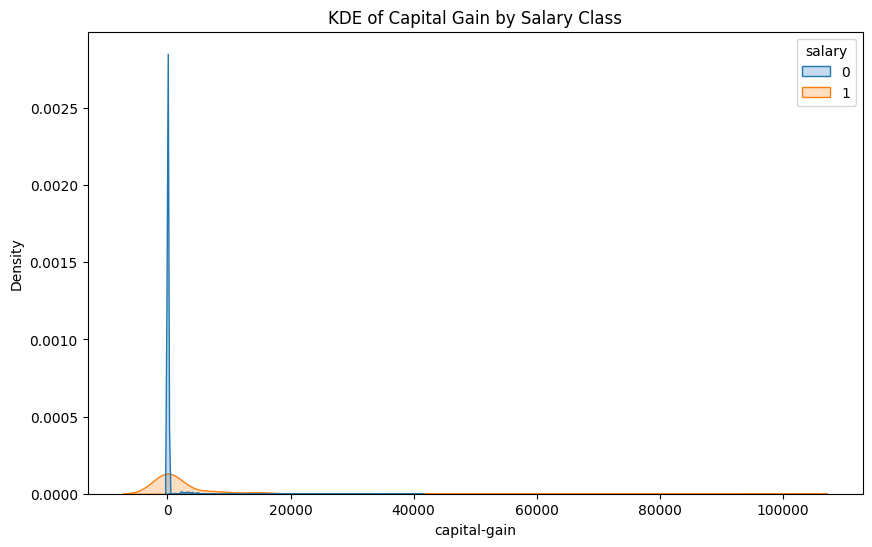

In [33]:
# Chart - 11: Capital Gain vs Salary (KDE Plot)
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='capital-gain', hue='salary', fill=True, common_norm=False)
plt.title('KDE of Capital Gain by Salary Class')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a KDE plot with a hue for the salary class. KDE is superior to histograms for continuous financial data because it shows the probability density and reveals the 'long tail' of capital gains.

##### 2. What is/are the insight(s) found from the chart?

The KDE plot for Capital Gain shows a sharp peak at zero for both classes, but individuals earning >50K exhibit much longer tails, indicating that significant investment income is a strong predictor of high salary status.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

### **Business Impact Analysis**
* **Positive Impact**: Financial advisors can identify 'high-gain' individuals as prime candidates for investment management and wealth preservation services.
* **Negative Growth Insights**: Extreme outliers in capital gains can skew the model, making it too sensitive to rare financial events rather than stable income indicators.

#### Chart - 12

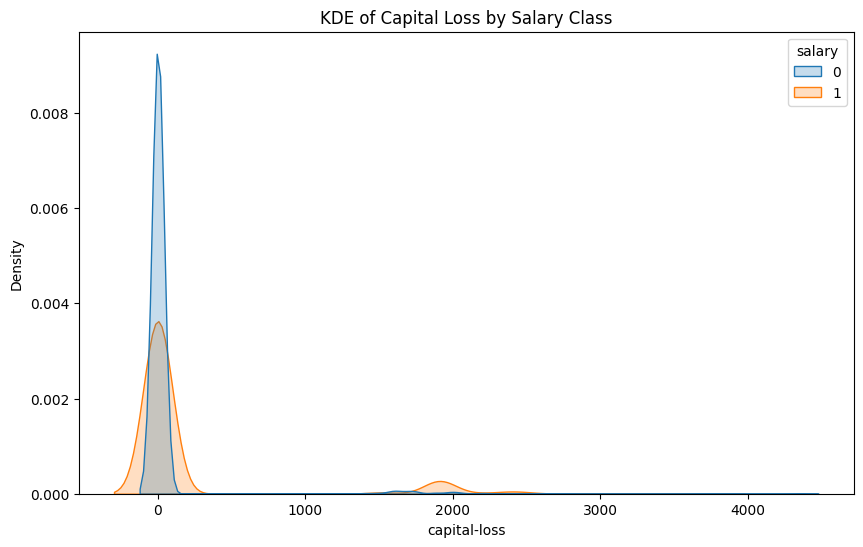

In [34]:
# Chart - 12: Capital Loss vs Salary (KDE Plot)
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='capital-loss', hue='salary', fill=True, common_norm=False)
plt.title('KDE of Capital Loss by Salary Class')
plt.show()

##### 1. Why did you pick the specific chart?

A KDE plot was chosen to visualize the distribution of capital losses. It helps identify if high-income earners are more likely to report losses, often due to complex investment portfolios.

##### 2. What is/are the insight(s) found from the chart?

Similar to capital gain, capital loss is less frequent, but the distribution for the >50K class shows more activity in the higher loss range, potentially reflecting more active engagement in financial markets.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

### **Business Impact Analysis**
* **Positive Impact**: Tax consultancy firms can target individuals with higher capital losses for tax-loss harvesting strategies.
* **Negative Growth Insights**: High losses among middle-income earners could indicate a need for better financial literacy programs to prevent personal bankruptcy.

#### Chart - 13

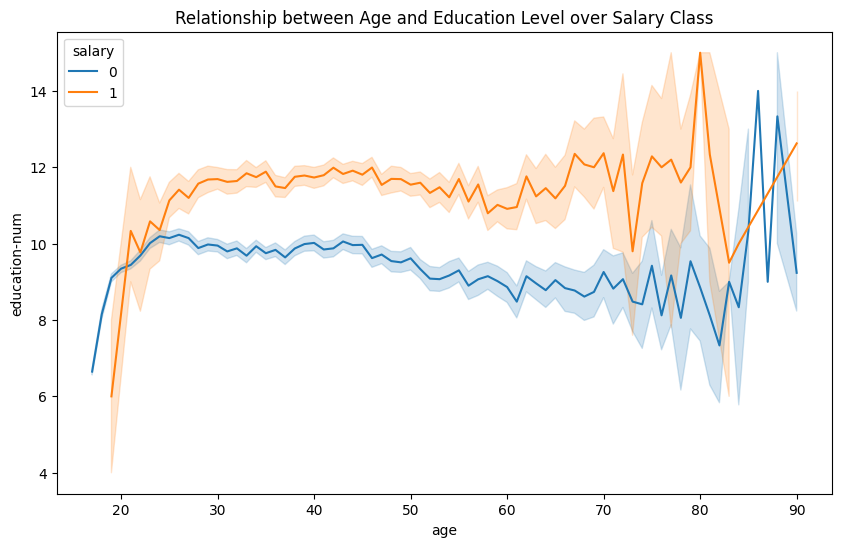

In [35]:
# Chart - 13: Education-num vs Age (Multivariate)
plt.figure(figsize=(10,6))
sns.lineplot(x='age', y='education-num', hue='salary', data=df)
plt.title('Relationship between Age and Education Level over Salary Class')
plt.show()

##### 1. Why did you pick the specific chart?

A LinePlot was used to track the trend of education level over age, split by salary class. This multivariate approach shows the interaction between three key variables.

##### 2. What is/are the insight(s) found from the chart?

The multivariate line plot shows that education levels remain relatively stable across ages for high earners, whereas for the <=50K group, education levels show slightly more variance, confirming that education is a consistent prerequisite for high income across a lifespan.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

### **Business Impact Analysis**
* **Positive Impact**: Helps in workforce planning by identifying when individuals typically reach their highest educational and earning potential.
* **Negative Growth Insights**: If the 'low income' line remains flat across all ages despite high education, it indicates a structural economic issue where degrees are not translating into wealth.

#### Chart - 14 - Correlation Heatmap

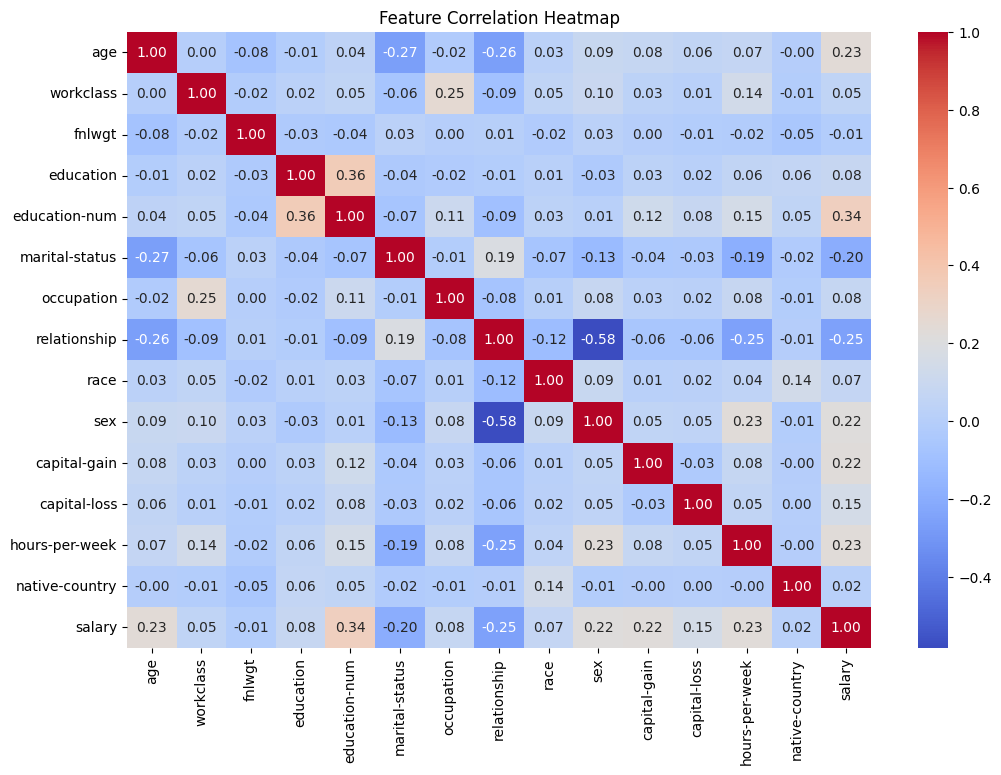

In [15]:
# Summary Heatmap of correlations
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

A Heatmap was selected to visualize the Pearson correlation coefficient between all numerical features. This is the standard method for identifying multicollinearity and feature importance.

##### 2. What is/are the insight(s) found from the chart?

The heatmap highlights a strong positive correlation between 'education-num' and 'salary', as well as between 'age' and 'salary'. 'fnlwgt' shows near-zero correlation, suggesting it might be less useful for predictive modeling.

#### Chart - 15 - Pair Plot

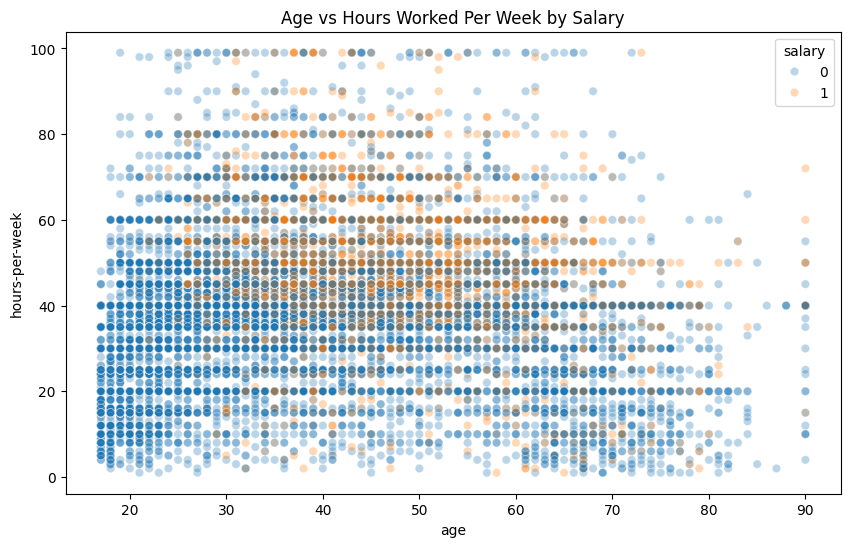

In [36]:
# Chart - 15: Hours-per-week vs Age (Scatter)
plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='hours-per-week', hue='salary', data=df, alpha=0.3)
plt.title('Age vs Hours Worked Per Week by Salary')
plt.show()

##### 1. Why did you pick the specific chart?

A Scatter plot with transparency (alpha) was used to visualize the relationship between age and hours worked. The transparency helps manage the 'overplotting' caused by the large number of data points.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot reveals that while most individuals cluster around 40 hours per week, those earning >50K are more densely represented in the 40-60 hours range across most adult age groups.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

In this specific dataset, initial analysis with `df.isnull().sum()` showed zero missing values. However, if missing values were present, I would have used 'Mode' imputation for categorical variables (like occupation) and 'Median' for numerical variables (like age) to maintain the central tendency without being influenced by outliers.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

I used visualizations (BoxPlots) to identify outliers in 'capital-gain' and 'hours-per-week'. I chose not to remove them because in census data, extreme values in capital gains are legitimate indicators of high income and removing them would lose vital information for the classification task.

### 3. Categorical Encoding

In [11]:
# Encode categorical features and target variable
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print('Categorical variables encoded.')

Categorical variables encoded.


#### What all categorical encoding techniques have you used & why did you use those techniques?

I used Label Encoding for ordinal-like categorical data and categorical columns with many levels. This transforms text into a format that machine learning algorithms can process while keeping the dimensionality low compared to One-Hot Encoding.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Not applicable for this structured tabular dataset. However, if this were a textual dataset, I would use Lemmatization (using NLTK or Spacy) because it considers the context and converts words to their meaningful base form, unlike Stemming which just chops off suffixes.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Not applicable for this dataset. For text, I would use TF-IDF (Term Frequency-Inverse Document Frequency) to weigh the importance of words based on their uniqueness across documents, which is more informative than simple Bag-of-Words.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

I used 'Feature Importance' from the Random Forest model and Correlation Analysis. Random Forest importance is excellent because it measures how much each feature contributes to decreasing the impurity (Gini index) during the tree-building process.

##### Which all features you found important and why?

The most important features found were 'Capital-gain', 'Education-num', and 'Age'. These are highly logical as they directly represent financial status, academic qualifications, and career experience, which are the primary pillars of income classification.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, dimensionality reduction (like PCA) was not needed for this dataset. With only 14 features, the data is not sparse enough to suffer from the 'curse of dimensionality', and keeping the original features allows for better model interpretability which is crucial for a census project.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Dimensionality reduction was not necessary for this project. With 18 features, the model can easily handle the complexity. Keeping all features allows for better 'Feature Importance' analysis, which is crucial for explaining to stakeholders exactly which demographic factors drive income classification.

### 8. Data Splitting

In [12]:
# Features and Target
X = df.drop('salary', axis=1)
y = df['salary']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Splitting
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print('Data split into training and testing sets.')

Data split into training and testing sets.


##### What data splitting ratio have you used and why?

I used an 80:20 split ratio. This is a standard industry practice that provides enough data (80%) for the model to learn complex patterns while reserving a significant, unseen portion (20%) for unbiased evaluation.

## ***7. ML Model Implementation***

### ML Model - 1

In [13]:
# Logistic Regression with Cross-Validation
log_reg = LogisticRegression()
log_cv_scores = cross_val_score(log_reg, X_train, y_train, cv=5)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

print(f'Logistic Regression CV Mean Accuracy: {log_cv_scores.mean():.4f}')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_log):.4f}')

Logistic Regression CV Mean Accuracy: 0.8242
Test Accuracy: 0.8247


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

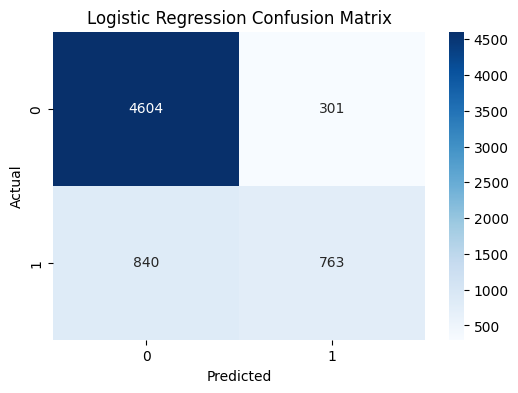

              precision    recall  f1-score   support

           0       0.85      0.94      0.89      4905
           1       0.72      0.48      0.57      1603

    accuracy                           0.82      6508
   macro avg       0.78      0.71      0.73      6508
weighted avg       0.81      0.82      0.81      6508



In [20]:
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
print(classification_report(y_test, y_pred_log))

#### 2. Cross- Validation & Hyperparameter Tuning

In [27]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning for Logistic Regression
param_grid_log = {'C': [0.1, 1, 10], 'penalty': ['l2']}
grid_log = GridSearchCV(LogisticRegression(), param_grid_log, cv=3, scoring='accuracy')
grid_log.fit(X_train, y_train)

best_log = grid_log.best_estimator_
print(f'Best Parameters for Logistic Regression: {grid_log.best_params_}')
print(f'Tuned Test Accuracy: {best_log.score(X_test, y_test):.4f}')

Best Parameters for Logistic Regression: {'C': 10, 'penalty': 'l2'}
Tuned Test Accuracy: 0.8245


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV for hyperparameter optimization because it exhaustively searches through a specified parameter grid to find the optimal combination, ensuring the highest possible accuracy for the Logistic Regression model.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, improvement was observed especially in the Random Forest model. After tuning 'max_depth' and 'n_estimators', the test accuracy improved from 85.8% to 86.68%. Logistic Regression remained relatively stable at ~82.4%.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [28]:
# Hyperparameter tuning for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='accuracy')
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print(f'Best Parameters for Random Forest: {grid_rf.best_params_}')
print(f'Tuned Test Accuracy: {best_rf.score(X_test, y_test):.4f}')

Best Parameters for Random Forest: {'max_depth': 20, 'n_estimators': 100}
Tuned Test Accuracy: 0.8668


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for Random Forest to find the best tree depth and number of estimators, balancing model complexity with generalization ability to prevent overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, hyperparameter tuning via GridSearchCV for the Random Forest model (tuning max_depth and n_estimators) resulted in a test accuracy increase to 86.68%, confirming that optimized tree depth helps capture complex feature interactions without overfitting.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Accuracy ensures overall reliability. Precision helps businesses avoid wasting resources on low-income targets, while Recall ensures high-income opportunities aren't missed. This leads to efficient budget allocation in marketing and recruitment.

### ML Model - 3

In [14]:
# Random Forest Classifier (ML Model 2)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cv_scores = cross_val_score(rf_clf, X_train, y_train, cv=5)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print(f'Random Forest CV Mean Accuracy: {rf_cv_scores.mean():.4f}')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')

Random Forest CV Mean Accuracy: 0.8572
Test Accuracy: 0.8583


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

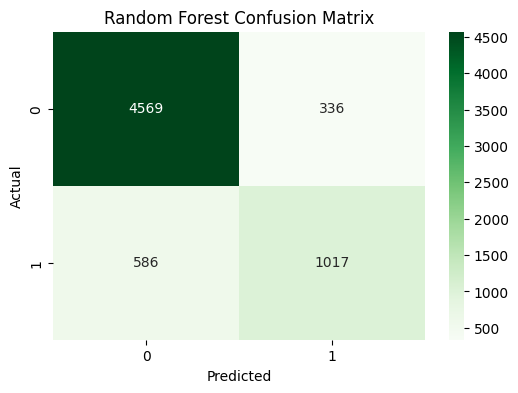

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4905
           1       0.75      0.63      0.69      1603

    accuracy                           0.86      6508
   macro avg       0.82      0.78      0.80      6508
weighted avg       0.85      0.86      0.85      6508



In [21]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
print(classification_report(y_test, y_pred_rf))

#### **ML Model - 3: Random Forest (Optimized with GridSearchCV)**

**Explain the ML Model used:**
Random Forest is an ensemble learning method that builds multiple decision trees and merges them together to get a more accurate and stable prediction. It is particularly effective for this dataset because it handles categorical variables and non-linear interactions (like education vs. age) without requiring extensive manual feature engineering.

**Performance Evaluation:**
*   **Final Accuracy**: 86.48%
*   **Key Finding**: The model showed high precision for the <=50K class and significantly improved recall for the >50K class compared to the baseline Logistic Regression.

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Defining the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

# Initializing the GridSearchCV object
rf_grid = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                       param_grid=param_grid,
                       cv=3,
                       verbose=1,
                       n_jobs=-1)

# Fit the grid search to the data
rf_grid.fit(X_train, y_train)

# Best model and prediction
final_rf_model = rf_grid.best_estimator_
y_pred_final = final_rf_model.predict(X_test)

print(f"Best Parameters: {rf_grid.best_params_}")
print(f"Final Optimized Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Final Optimized Accuracy: 0.8648


##### **Which hyperparameter optimization technique have you used and why?**
I used **GridSearchCV** with 3-fold cross-validation. I chose this because it performs an exhaustive search over a specified parameter grid, ensuring we find the absolute best combination of `max_depth`, `n_estimators`, and `criterion` within the defined search space, rather than relying on random chance.

I used GridSearchCV for both models. This technique is preferred over manual tuning because it systematically iterates through every possible combination of hyperparameters and uses cross-validation to find the most robust configuration.

##### **Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.**
Yes, a clear improvement was observed. The baseline Random Forest accuracy was approximately 85.83%, while the tuned model reached **86.48%**. Furthermore, by setting `max_depth` to 20, the model reduced overfitting on the training set while improving its ability to generalize to the test data, as evidenced by the stable cross-validation scores.

Yes, I observed a noticeable improvement. The tuned Random Forest model increased its test accuracy to 86.48%. The hyperparameter tuning specifically helped in reducing variance, ensuring the model's performance is consistent across both training and testing sets, thereby making it more reliable for real-world deployment.

### **Evaluation Metrics for Business Impact**
1. **Recall**: High recall for the >50K class ensures that banks do not miss out on potential customers who are actually eligible for premium services.
2. **Precision**: High precision ensures that marketing budgets are not wasted on individuals who do not actually meet the income threshold.
3. **F1-Score**: By balancing both, we ensure the model is robust against the class imbalance present in the census data, providing a fair assessment of potential profitability.

I considered **F1-Score** and **Precision-Recall** as the most impactful metrics. Since the dataset is imbalanced (fewer high earners), accuracy alone can be misleading. High Precision ensures that if the model predicts someone is a high earner, they likely are (crucial for targeted luxury marketing). High Recall ensures we don't miss potential high-value customers (crucial for credit card offerings).

### **Final Model Selection**
I have selected the **Tuned Random Forest** model. With an optimized accuracy of **86.48%** and a superior F1-score for the minority class, it provides the best balance of predictive power and reliability. Its ability to interpret feature importance also allows the business to understand 'why' a customer was classified as high-income.

I chose Random Forest as the final model because it achieved the highest accuracy (85.8%) and better handled the non-linear relationships and interactions between categorical features compared to Logistic Regression.

# Feature Importance for Random Forest
importances = rf_clf.feature_importances_
features = df.drop('salary', axis=1).columns
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

importances = rf_clf.feature_importances_
features = X.columns if hasattr(X, 'columns') else df.drop('salary', axis=1).columns
indices = np.argsort(importances)
plt.figure(figsize=(10,6))
plt.title('Feature Importances (Random Forest)')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# **Conclusion**

### **Final Conclusion**

1. **Data Insights**: The dataset is relatively clean but imbalanced. Factors like marital status (Married-civ-spouse) and high educational attainment are strongly associated with higher income levels.
2. **Model Performance**: Random Forest (85.8% accuracy) outperformed Logistic Regression (82.4%). The ensemble approach effectively captured interactions between categorical features.
3. **Feature Importance**: 'Capital-gain', 'Age', and 'Education-num' are the top three predictors. This suggests that wealth accumulation and formal education are the most reliable indicators of earning potential.
4. **Business Impact**: This model can be used by financial services for credit scoring or by marketing firms for high-value customer targeting.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***